<a href="https://colab.research.google.com/github/yuvanesh2356/DAA-LAB-EXPERIMENT/blob/main/DAA_Exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter number of student roll numbers: 5
Enter sorted roll numbers:
12
14
16
18
30

Enter roll number to search: 18

SEARCH RESULT
----------------------------------------
Roll Number Found at Position : 4

COMPARISON TABLE
              Algorithm  Probes
0  Interpolation Search       3
1         Binary Search       2


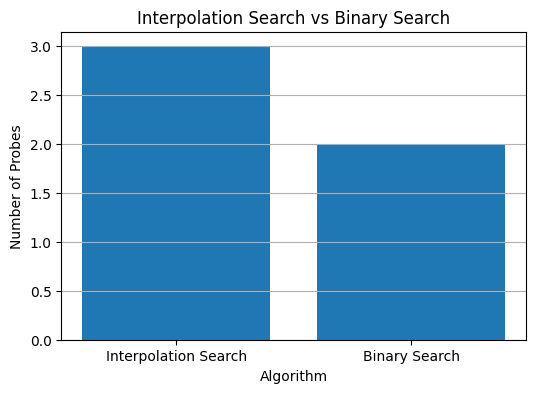


PERFORMANCE COMPARISON
------------------------------------------------------------
      Size    IS Probes    BS Probes
      1000            1            9
      5000            1           13
     10000            1            9
     50000            1           15
    100000            1           17


[[1000, 1, 9], [5000, 1, 13], [10000, 1, 9], [50000, 1, 15], [100000, 1, 17]]

In [9]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt


def interpolation_search(arr, target):
    """
    Interpolation Search Algorithm
    Time Complexity: O(log log n) average, O(n) worst case
    Space Complexity: O(1)
    """

    low, high = 0, len(arr) - 1
    probes = 0

    while low <= high and arr[low] <= target <= arr[high]:

        probes += 1

        if low == high:
            if arr[low] == target:
                return low, probes
            return -1, probes

        pos = low + int(
            ((target - arr[low]) * (high - low))
            / (arr[high] - arr[low])
        )

        if arr[pos] == target:
            return pos, probes

        elif arr[pos] < target:
            low = pos + 1

        else:
            high = pos - 1

    return -1, probes


def binary_search(arr, target):
    """
    Binary Search Algorithm
    Time Complexity: O(log n)
    Space Complexity: O(1)
    """

    low, high = 0, len(arr) - 1
    probes = 0

    while low <= high:

        probes += 1

        mid = (low + high) // 2

        if arr[mid] == target:
            return mid, probes

        elif arr[mid] < target:
            low = mid + 1

        else:
            high = mid - 1

    return -1, probes


def performance_analysis():
    print("\nPERFORMANCE COMPARISON")
    print("-" * 60)

    sizes = [1000, 5000, 10000, 50000, 100000]

    results = []

    print(f"{'Size':>10} {'IS Probes':>12} {'BS Probes':>12}")

    for size in sizes:

        roll_numbers = list(range(1, size + 1))

        target = random.choice(roll_numbers)

        _, is_probes = interpolation_search(roll_numbers, target)
        _, bs_probes = binary_search(roll_numbers, target)

        results.append([size, is_probes, bs_probes])

        print(f"{size:>10} {is_probes:>12} {bs_probes:>12}")

    return results


# ---------------- MAIN PROGRAM ----------------

n = int(input("Enter number of student roll numbers: "))

roll_numbers = []

print("Enter sorted roll numbers:")

for i in range(n):
    roll_numbers.append(int(input()))

target = int(input("\nEnter roll number to search: "))

# Interpolation Search
idx_is, probes_is = interpolation_search(roll_numbers, target)

# Binary Search
idx_bs, probes_bs = binary_search(roll_numbers, target)

print("\nSEARCH RESULT")
print("-" * 40)

if idx_is != -1:
    print(f"Roll Number Found at Position : {idx_is + 1}")
else:
    print("Roll Number Not Found")

# Comparison Table
comparison_table = pd.DataFrame({
    "Algorithm": ["Interpolation Search", "Binary Search"],
    "Probes": [probes_is, probes_bs]
})

print("\nCOMPARISON TABLE")
print(comparison_table)

# Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(comparison_table["Algorithm"],
        comparison_table["Probes"])

plt.title("Interpolation Search vs Binary Search")
plt.xlabel("Algorithm")
plt.ylabel("Number of Probes")
plt.grid(axis='y')

plt.show()

# Performance Analysis
performance_analysis()